In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib as mpl
from pynamicalsys import ContinuousDynamicalSystem as cds, PlotStyler

In [2]:
ds = cds(model="lorenz system")

In [3]:
total_time = 1000
transient_time = 500
u = [1, 1, 1]
parameters = [10, 28, 8/3]
ds.set_parameters(parameters)
time_step = 1e-2

In [4]:
ds.integrator("rk4", time_step=time_step)
trajectory = ds.trajectory(u, total_time, parameters=parameters, transient_time=transient_time)
trajectory.shape # time, x, y, z

(50001, 4)

In [5]:
subspaces = [([0], [1, 2]), ([0, 1], [2]), ([0], [1]), ([0], [2])]
angles, traj = ds.CLV_angles(u, total_time, subspaces=subspaces, transient_time=transient_time)

In [6]:
traj.shape, angles.shape

((50001, 4), (50001, 4))

<Figure size 640x480 with 0 Axes>

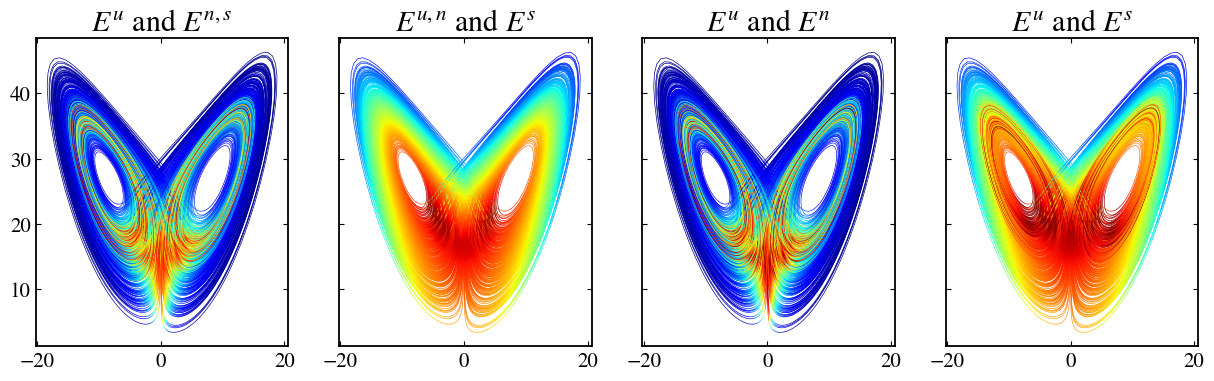

In [7]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(15, 4))


# x, y coordinates
x = traj[:, 1]
y = traj[:, 3]
# Build line segments
points = np.column_stack([x, y])
segments = np.stack([points[:-1], points[1:]], axis=1)

c = angles[:, 0]  # shape (T,)
c_seg = 0.5 * (c[:-1] + c[1:])
lc = LineCollection(
    segments,
    array=c_seg,
    cmap="jet",
    linewidth=0.5,
    norm=mpl.colors.Normalize(vmin=0,vmax=np.pi/2)
)
ax[0].add_collection(lc)
ax[0].autoscale()
ax[0].set_title("$E^{u}$ and $E^{n, s}$")

c = angles[:, 1]  # shape (T,)
c_seg = 0.5 * (c[:-1] + c[1:])
lc = LineCollection(
    segments,
    array=c_seg,
    cmap="jet",
    linewidth=0.5,
    norm=mpl.colors.Normalize(vmin=0,vmax=np.pi/2)
)
ax[1].set_title("$E^{u, n}$ and $E^{s}$")
ax[1].add_collection(lc)
ax[1].autoscale()

c = angles[:, 2]  # shape (T,)
c_seg = 0.5 * (c[:-1] + c[1:])
lc = LineCollection(
    segments,
    array=c_seg,
    cmap="jet",
    linewidth=0.5,
    norm=mpl.colors.Normalize(vmin=0,vmax=np.pi/2)
)
ax[2].set_title("$E^{u}$ and $E^{n}$")
ax[2].add_collection(lc)
ax[2].autoscale()

c = angles[:, 3]  # shape (T,)
c_seg = 0.5 * (c[:-1] + c[1:])
lc = LineCollection(
    segments,
    array=c_seg,
    cmap="jet",
    linewidth=0.5,
    norm=mpl.colors.Normalize(vmin=0,vmax=np.pi/2)
)
ax[3].set_title("$E^{u}$ and $E^{s}$")
ax[3].add_collection(lc)
ax[3].autoscale()